##Import libraries

In [ ]:
#import libraries
import torch
import torchvision
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
import torch.utils.data as dataloader
import torch.nn as nn

##Transformation of PIL into tensor format

In [ ]:
#transformation of PIL into tensor format
transformation_operation = transforms.Compose([transforms.ToTensor()])

##Downloading datasets from torchvision.datasets

In [ ]:
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transformation_operation)
val_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transformation_operation)

##Dataloader for creating batches

In [ ]:
train_loader = dataloader.DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader  = dataloader.DataLoader(val_dataset, batch_size=64, shuffle=False)

##Define variables

In [ ]:
#define variables
batch_size = 64
num_classes = 10
num_channels = 1
img_size = 28
patch_size = 7
patch_num = (img_size//patch_size)**2
attention_heads = 4
embed_dim = 64
transformer_blocks = 4
mlp_nodes = 128
learning_rate = 3e-4
epochs = 5

##Part 1: Patch embedding

In [ ]:
# class for patch embedding - Part 1 of the ViT
class PatchEmbedding(nn.Module):
  def __init__(self):
    super().__init__()
    self.patch_embed = nn.Conv2d(num_channels, embed_dim, kernel_size = patch_size, stride = patch_size)

  def forward(self, x):
    x = self.patch_embed(x)
    x = x.flatten(2)
    x = x.transpose(1,2)
    return x

##Part 2: Transformer encoder

In [ ]:
# class for transformer encoder - Part 2 of the ViT
class TransformerEncoder(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_norm1 = nn.LayerNorm(embed_dim)
    self.multi_head_attention = nn.MultiheadAttention(embed_dim, attention_heads, batch_first=True)
    self.layer_norm2 = nn.LayerNorm(embed_dim)
    self.mlp = nn.Sequential(
        nn.Linear(embed_dim, mlp_nodes),
        nn.GELU(),
        nn.Linear(mlp_nodes, embed_dim)
    )

  def forward(self, x):
    residual1 = x
    x = self.layer_norm1(x)
    x = self.multi_head_attention(x, x, x)[0]
    x = x + residual1

    residual2 = x
    x = self.layer_norm2(x)
    x = self.mlp(x)
    x = x + residual2

    return x

##Part 3: MLP

In [ ]:
# MLP head Part 3 of the ViT
class MLP_Head(nn.Module):
  def __init__(self):
    super().__init__()
    self.layernorm1 = nn.LayerNorm(embed_dim)
    self.mlp_head = nn.Linear(embed_dim, num_classes)

  def forward(self, x):
    # x = x[:,0]
    x = self.layernorm1(x)
    x = self.mlp_head(x)
    return x

##Overall vision transformer class

In [ ]:
class VisionTransformer(nn.Module):
  def __init__(self):
    super().__init__()
    self.patch_embedding = PatchEmbedding()
    self.cls_token = nn.Parameter(torch.randn(1,1,embed_dim))
    self.position_embedding = nn.Parameter(torch.randn(1,patch_num+1, embed_dim))
    self.transformer_blocks = nn.Sequential(*[TransformerEncoder() for _ in range(transformer_blocks)])
    self.mlp_head = MLP_Head()

  def forward(self, x):
    x = self.patch_embedding(x)
    B = x.size(0)
    cls_tokens = self.cls_token.expand(B, -1, -1)
    x = torch.cat((cls_tokens, x), dim = 1)
    x = x + self.position_embedding
    x = self.transformer_blocks(x)
    x = x[:,0]
    x = self.mlp_head(x)
    return x

##Device, model, optimizer and loss

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = VisionTransformer().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss()

##Training loops for batches

In [ ]:
for epoch in range(5):
    model.train()
    total_loss = 0
    correct_epoch = 0
    total_epoch = 0
    print(f"\nEpoch {epoch+1}")

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct = (preds == labels).sum().item()
        accuracy = 100.0 * correct / labels.size(0)

        correct_epoch += correct
        total_epoch += labels.size(0)

        if batch_idx % 100 == 0:
            print(f"  Batch {batch_idx+1:3d}: Loss = {loss.item():.4f}, Accuracy = {accuracy:.2f}%")

    epoch_acc = 100.0 * correct_epoch / total_epoch
    print(f"==> Epoch {epoch+1} Summary: Total Loss = {total_loss:.4f}, Accuracy = {epoch_acc:.2f}%")


Epoch 1
  Batch   1: Loss = 2.4563, Accuracy = 7.81%
  Batch 101: Loss = 1.0802, Accuracy = 75.00%
  Batch 201: Loss = 0.5037, Accuracy = 85.94%
  Batch 301: Loss = 0.3887, Accuracy = 90.62%
  Batch 401: Loss = 0.2612, Accuracy = 90.62%
  Batch 501: Loss = 0.3301, Accuracy = 90.62%
  Batch 601: Loss = 0.2041, Accuracy = 93.75%
  Batch 701: Loss = 0.2475, Accuracy = 92.19%
  Batch 801: Loss = 0.2510, Accuracy = 92.19%
  Batch 901: Loss = 0.0514, Accuracy = 100.00%
==> Epoch 1 Summary: Total Loss = 516.0980, Accuracy = 82.92%

Epoch 2
  Batch   1: Loss = 0.2794, Accuracy = 90.62%
  Batch 101: Loss = 0.2255, Accuracy = 90.62%
  Batch 201: Loss = 0.0807, Accuracy = 96.88%
  Batch 301: Loss = 0.0557, Accuracy = 100.00%
  Batch 401: Loss = 0.2000, Accuracy = 95.31%
  Batch 501: Loss = 0.0956, Accuracy = 96.88%
  Batch 601: Loss = 0.1281, Accuracy = 95.31%
  Batch 701: Loss = 0.1166, Accuracy = 96.88%
  Batch 801: Loss = 0.2514, Accuracy = 92.19%
  Batch 901: Loss = 0.1310, Accuracy = 93.75%

##Validation accuracy calculation

In [ ]:
# Switch to evaluation mode
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

test_acc = 100.0 * correct / total
print(f"\n==> Val Accuracy: {test_acc:.2f}%")


==> Val Accuracy: 97.42%


##Testing on some random images

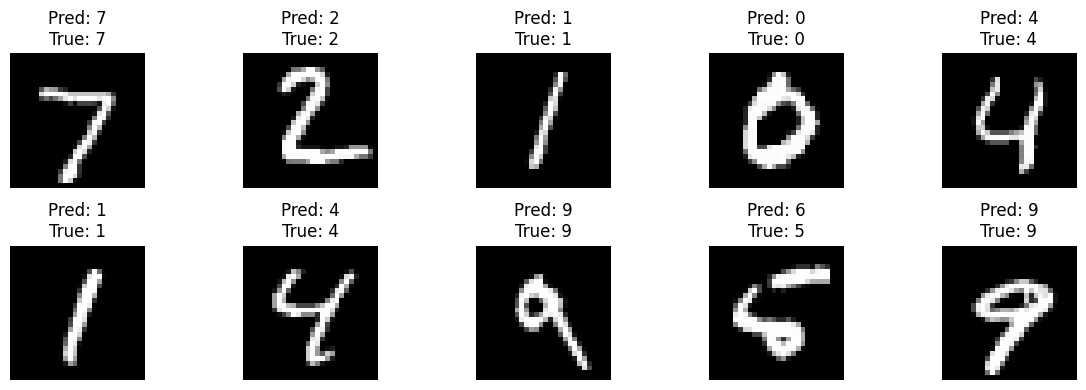

In [ ]:
import matplotlib.pyplot as plt

# Show 10 predictions from the first test batch
model.eval()
images, labels = next(iter(val_loader))
images, labels = images.to(device), labels.to(device)
with torch.no_grad():
    outputs = model(images)
    preds = outputs.argmax(dim=1)

# Move to CPU for plotting
images = images.cpu()
preds = preds.cpu()
labels = labels.cpu()

# Plot first 10 images
plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title(f"Pred: {preds[i].item()}\nTrue: {labels[i].item()}")
    plt.axis('off')
plt.tight_layout()
plt.show()